# nSpikeTrainExamples

The nspikeTrain class.

Python port of the MATLAB `nSpikeTrainExamples` helpfile (`helpfiles/nSpikeTrainExamples.m`).

In [ ]:
from pathlib import Path
import sys
REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from nstat import SignalObj, Covariate, CovColl, Events, nspikeTrain, nstColl
from nstat.notebook_figures import FigureTracker
np.random.seed(0)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic="nSpikeTrainExamples", output_root=OUTPUT_ROOT, expected_count=7)

def capture(label, fn):
    """Save any prior figure, then run ``fn`` on a clean canvas and register
    the result with the tracker. Bypasses the placeholder so axis ticks,
    labels, spines, and titles are preserved (no set_axis_off() leakage,
    no overlapping annotation text)."""
    __tracker._save_active()
    __tracker.count += 1
    plt.close("all")
    # MATLAB default figure aspect is ~4:3 (560x420 px); 8.0x4.5 produces a
    # much wider/shorter panel than the helpfile output. Use a 4:3 figsize
    # so the Python panels match MATLAB's proportions.
    fig = plt.figure(figsize=(7.0, 5.25))
    fig.add_subplot(1, 1, 1)
    fn()
    __tracker._active_fig = plt.gcf()
    __tracker._active_ax = plt.gca()


In [ ]:
# SECTION 1: Test the nspikeTrain Class
# MATLAB helpfile §1 is a header-only section with no calls; this Python
# cell mirrors that boundary so downstream sections align 1:1 with the
# MATLAB %% markers.


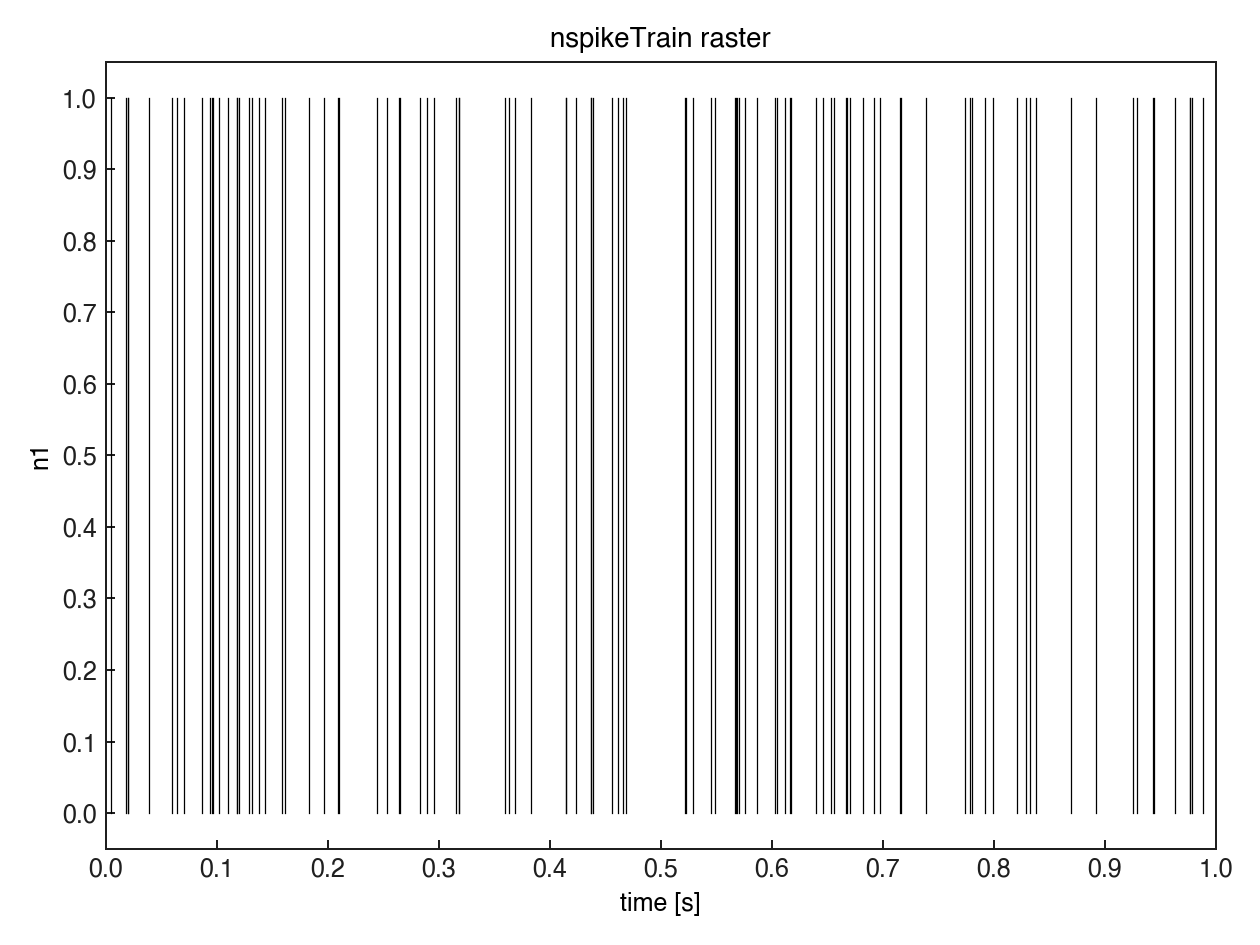

In [ ]:
# SECTION 2: Example 1: Using the nspikeTrain Class
# MATLAB:
#   spikeTimes = sort(rand(1,100))*1;
#   spikeTimes = unique(round(spikeTimes*10000)./10000);
#   nst = nspikeTrain(spikeTimes,'n1',.001,0,1);
#   figure; nst.plot;
spikeTimes = np.sort(np.random.rand(100))
spikeTimes = np.unique(np.round(spikeTimes * 10000) / 10000)
nst = nspikeTrain(spikeTimes, "n1", 1000, 0, 1)  # MATLAB binwidth .001 -> sampleRate 1000

def _raster():
    nst.plot()
    ax = plt.gca()
    ax.set_xlabel("time [s]")
    ax.set_ylabel("n1")
    ax.set_xticks(np.linspace(0, 1, 11))
    ax.set_yticks(np.linspace(0, 1, 11))
    ax.set_title("nspikeTrain raster")
    plt.tight_layout()

capture("nst.plot() — raster", _raster)


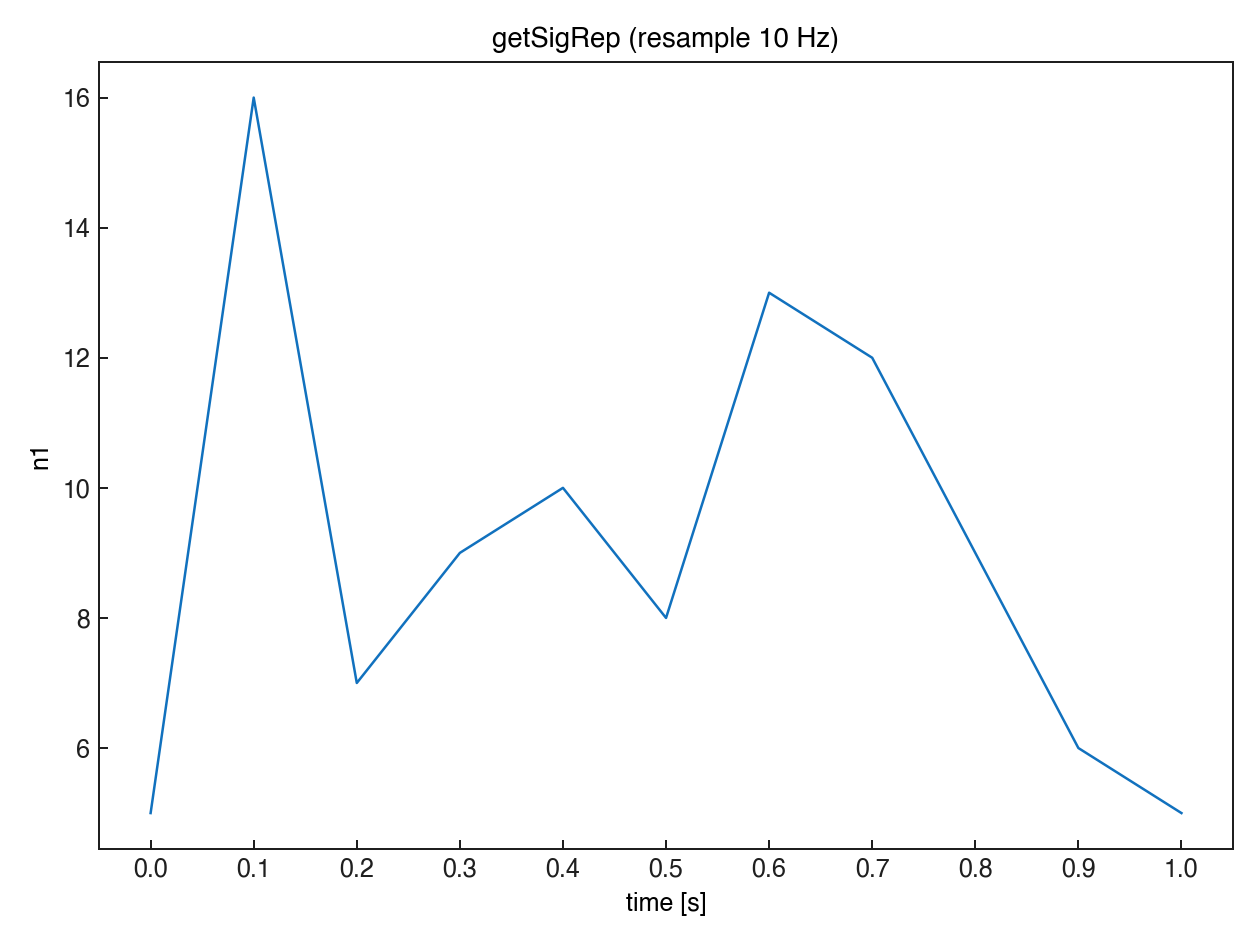

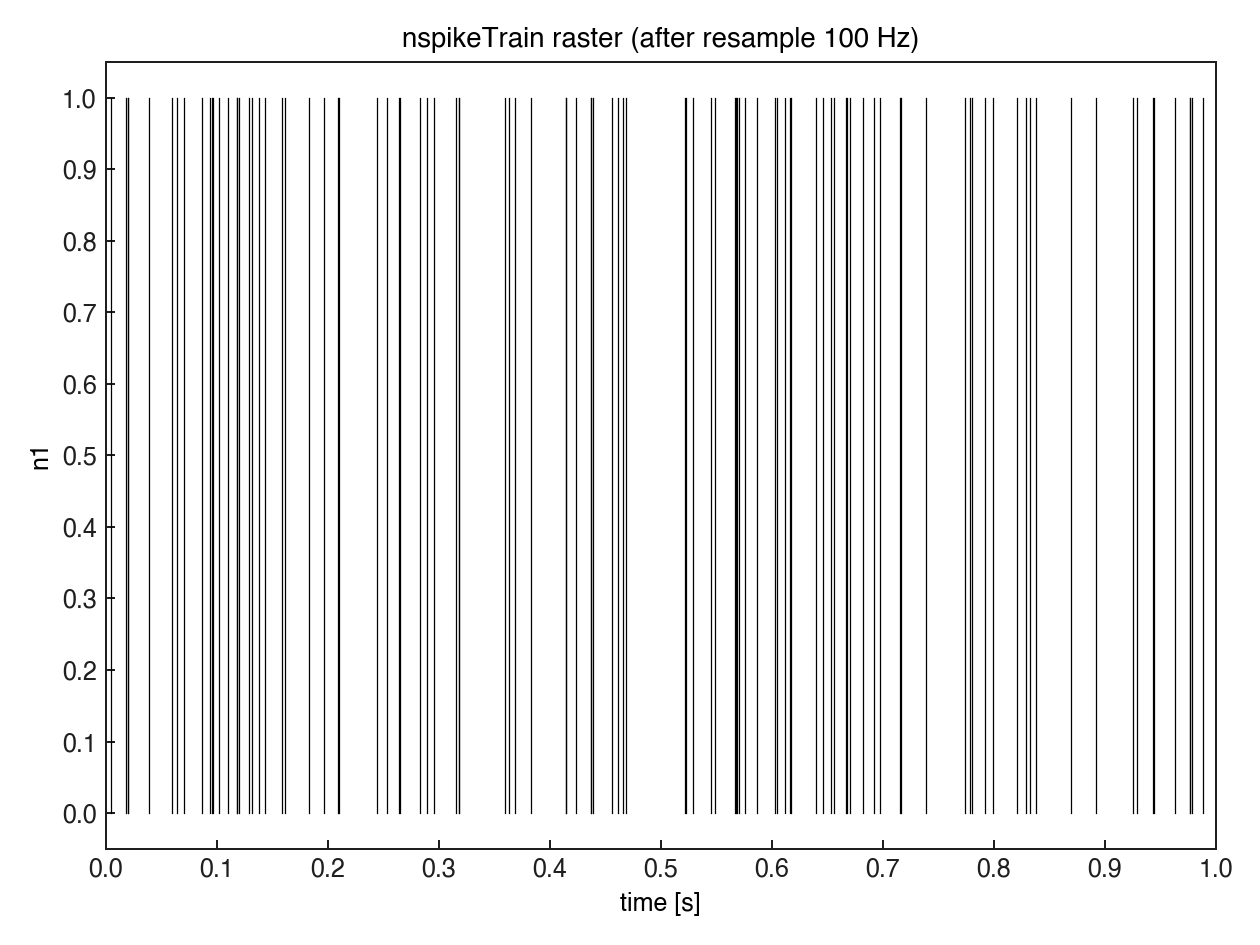

In [ ]:
# SECTION 3: (untitled section)
# MATLAB:
#   figure; nst.resample(1/.1);
#   nst.getSigRep.plot;
# 100ms bins from 0 to 10 sec — getSigRep does not change the underlying
# nspikeTrain representation.

def _sig10():
    nst.resample(10); nst.getSigRep().plot()
    ax = plt.gca()
    ax.set_xlabel("time [s]")
    ax.set_ylabel("n1")
    ax.set_xticks(np.linspace(0, 1, 11))
    ax.set_title("getSigRep (resample 10 Hz)")
    plt.tight_layout()

capture("signal rep @ 10 Hz", _sig10)

# MATLAB live-editor auto-rendered the nspikeTrain object as a raster after
# the resample (helpfiles/nSpikeTrainExamples_03.png). Mirror that here.
def _raster_resampled():
    nst.resample(100); nst.plot()
    ax = plt.gca()
    ax.set_xlabel("time [s]")
    ax.set_ylabel("n1")
    ax.set_xticks(np.linspace(0, 1, 11))
    ax.set_yticks(np.linspace(0, 1, 11))
    ax.set_title("nspikeTrain raster (after resample 100 Hz)")
    plt.tight_layout()

capture("nst.plot() raster after 100 Hz resample", _raster_resampled)


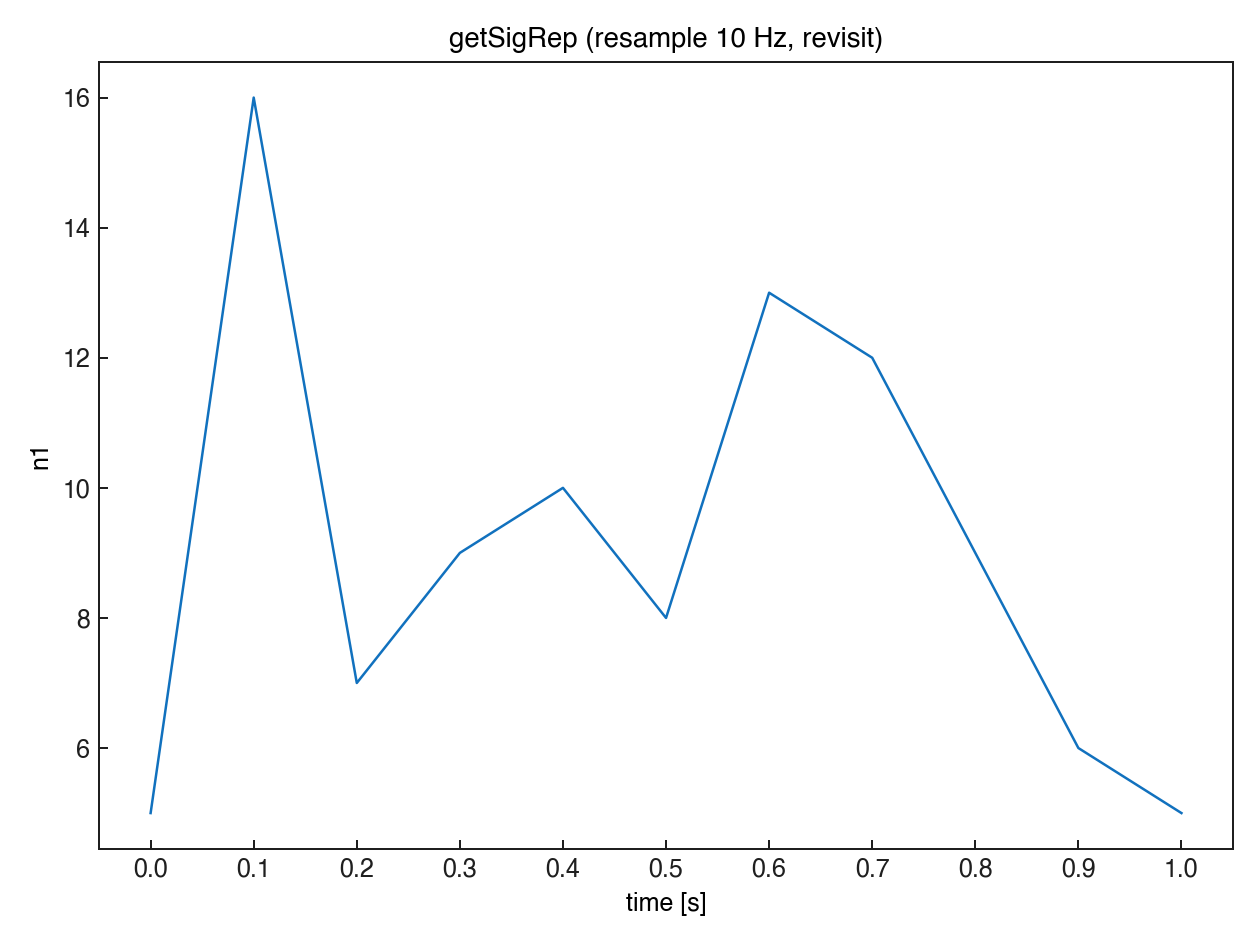

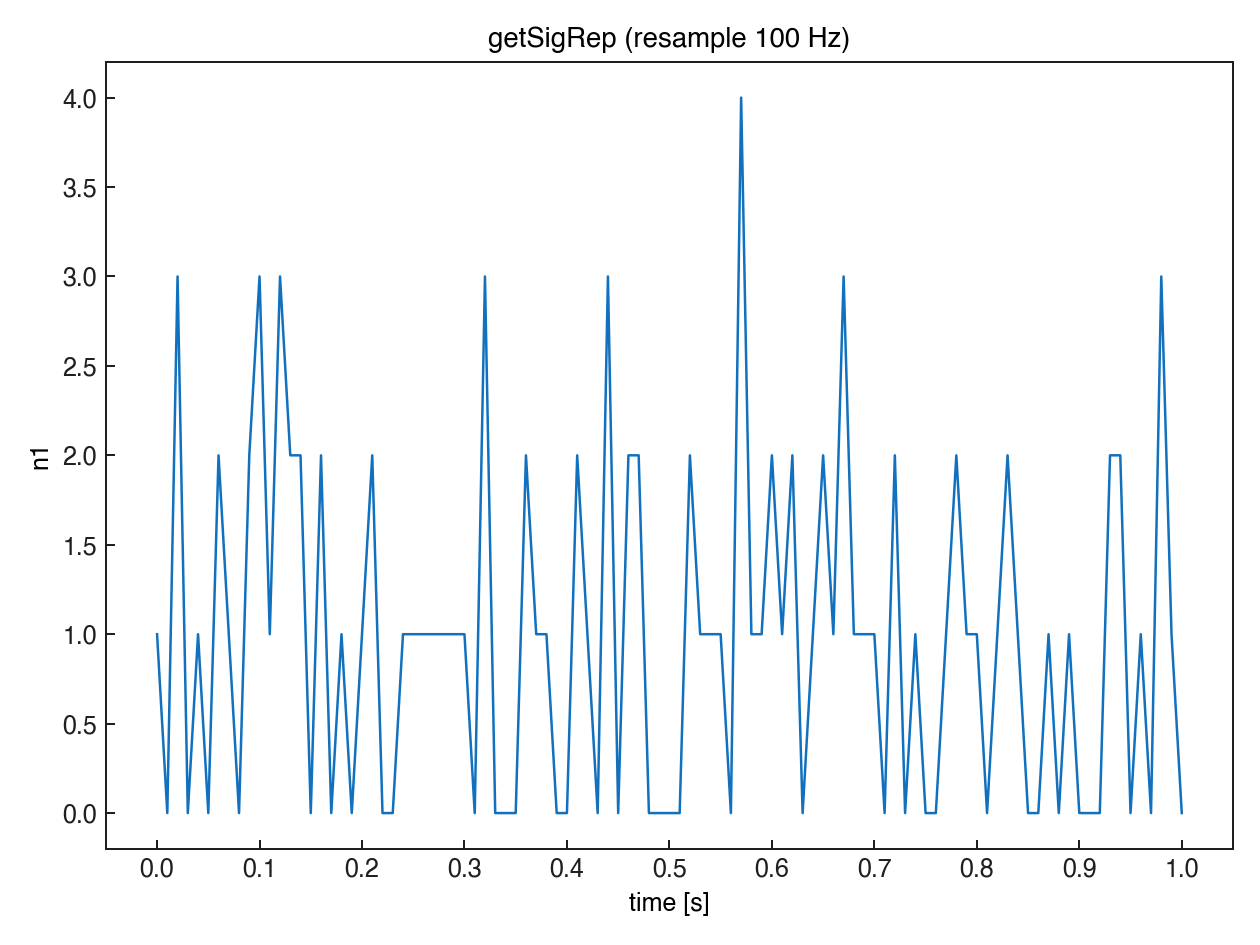

In [ ]:
# SECTION 4: (untitled section)
# MATLAB:
#   figure; nst.resample(1/.01);
#   nst.getSigRep.plot;
# 10ms bins from 0 to 10 sec — actually changing the representation of the
# signal.

# MATLAB live-editor also re-rendered the 10 Hz signal representation in
# the 100 Hz section (helpfiles/nSpikeTrainExamples_04.png). Mirror that here.
def _sig10_revisit():
    nst.resample(10); nst.getSigRep().plot()
    ax = plt.gca()
    ax.set_xlabel("time [s]")
    ax.set_ylabel("n1")
    ax.set_xticks(np.linspace(0, 1, 11))
    ax.set_title("getSigRep (resample 10 Hz, revisit)")
    plt.tight_layout()

capture("signal rep @ 10 Hz (revisit)", _sig10_revisit)

def _sig100():
    nst.resample(100); nst.getSigRep().plot()
    ax = plt.gca()
    ax.set_xlabel("time [s]")
    ax.set_ylabel("n1")
    ax.set_xticks(np.linspace(0, 1, 11))
    ax.set_title("getSigRep (resample 100 Hz)")
    plt.tight_layout()

capture("signal rep @ 100 Hz", _sig100)


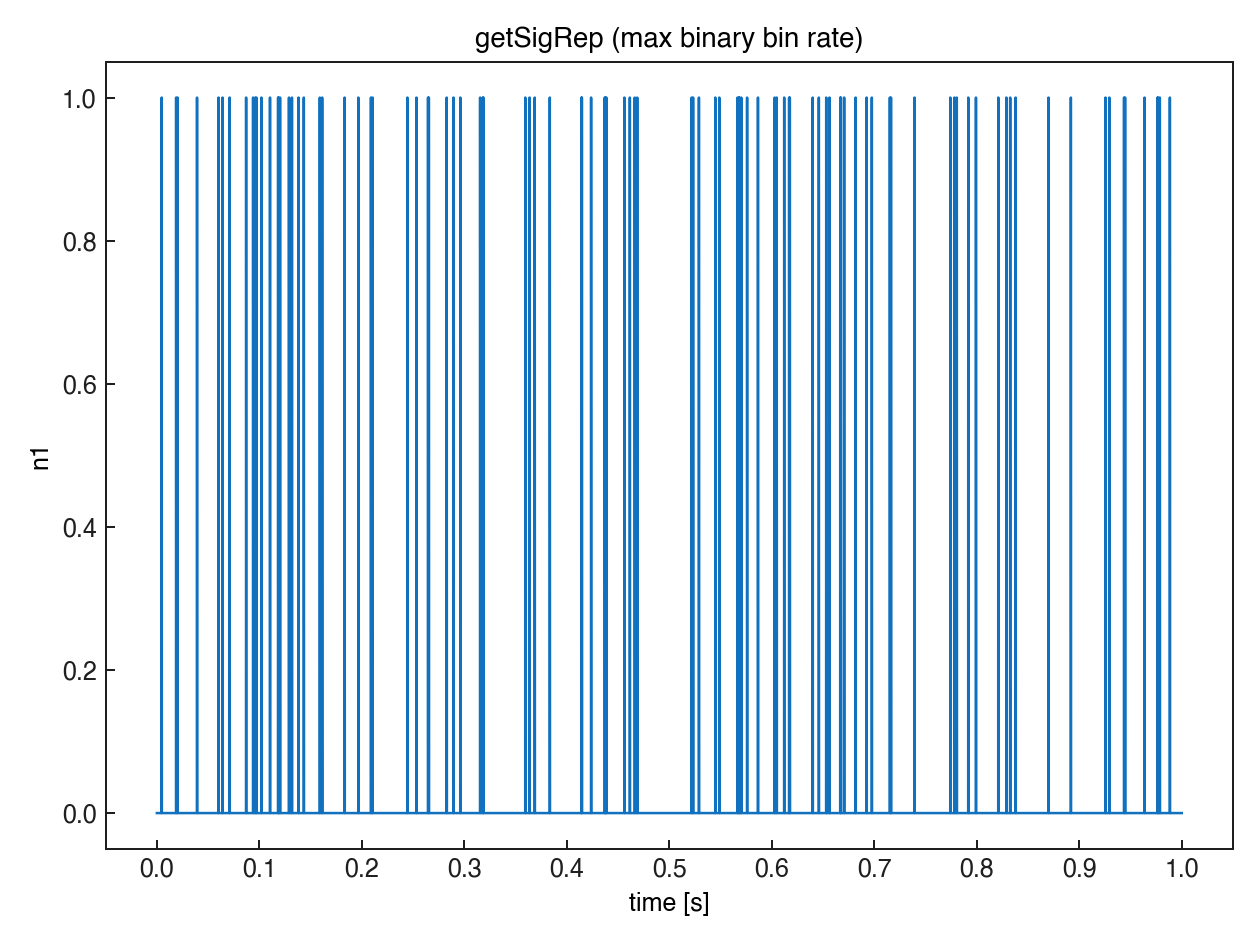

In [ ]:
# SECTION 5: (untitled section)
# MATLAB:
#   figure; nst.resample(1/nst.getMaxBinSizeBinary);
#   nst.getSigRep.plot;
# Get the largest binsize that still maintains a binary signal representation.

def _sig_bin():
    nst.resample(1.0 / nst.getMaxBinSizeBinary()); nst.getSigRep().plot()
    ax = plt.gca()
    ax.set_xlabel("time [s]")
    ax.set_ylabel("n1")
    ax.set_xticks(np.linspace(0, 1, 11))
    ax.set_title("getSigRep (max binary bin rate)")
    plt.tight_layout()

capture("signal rep @ max binary bin rate", _sig_bin)


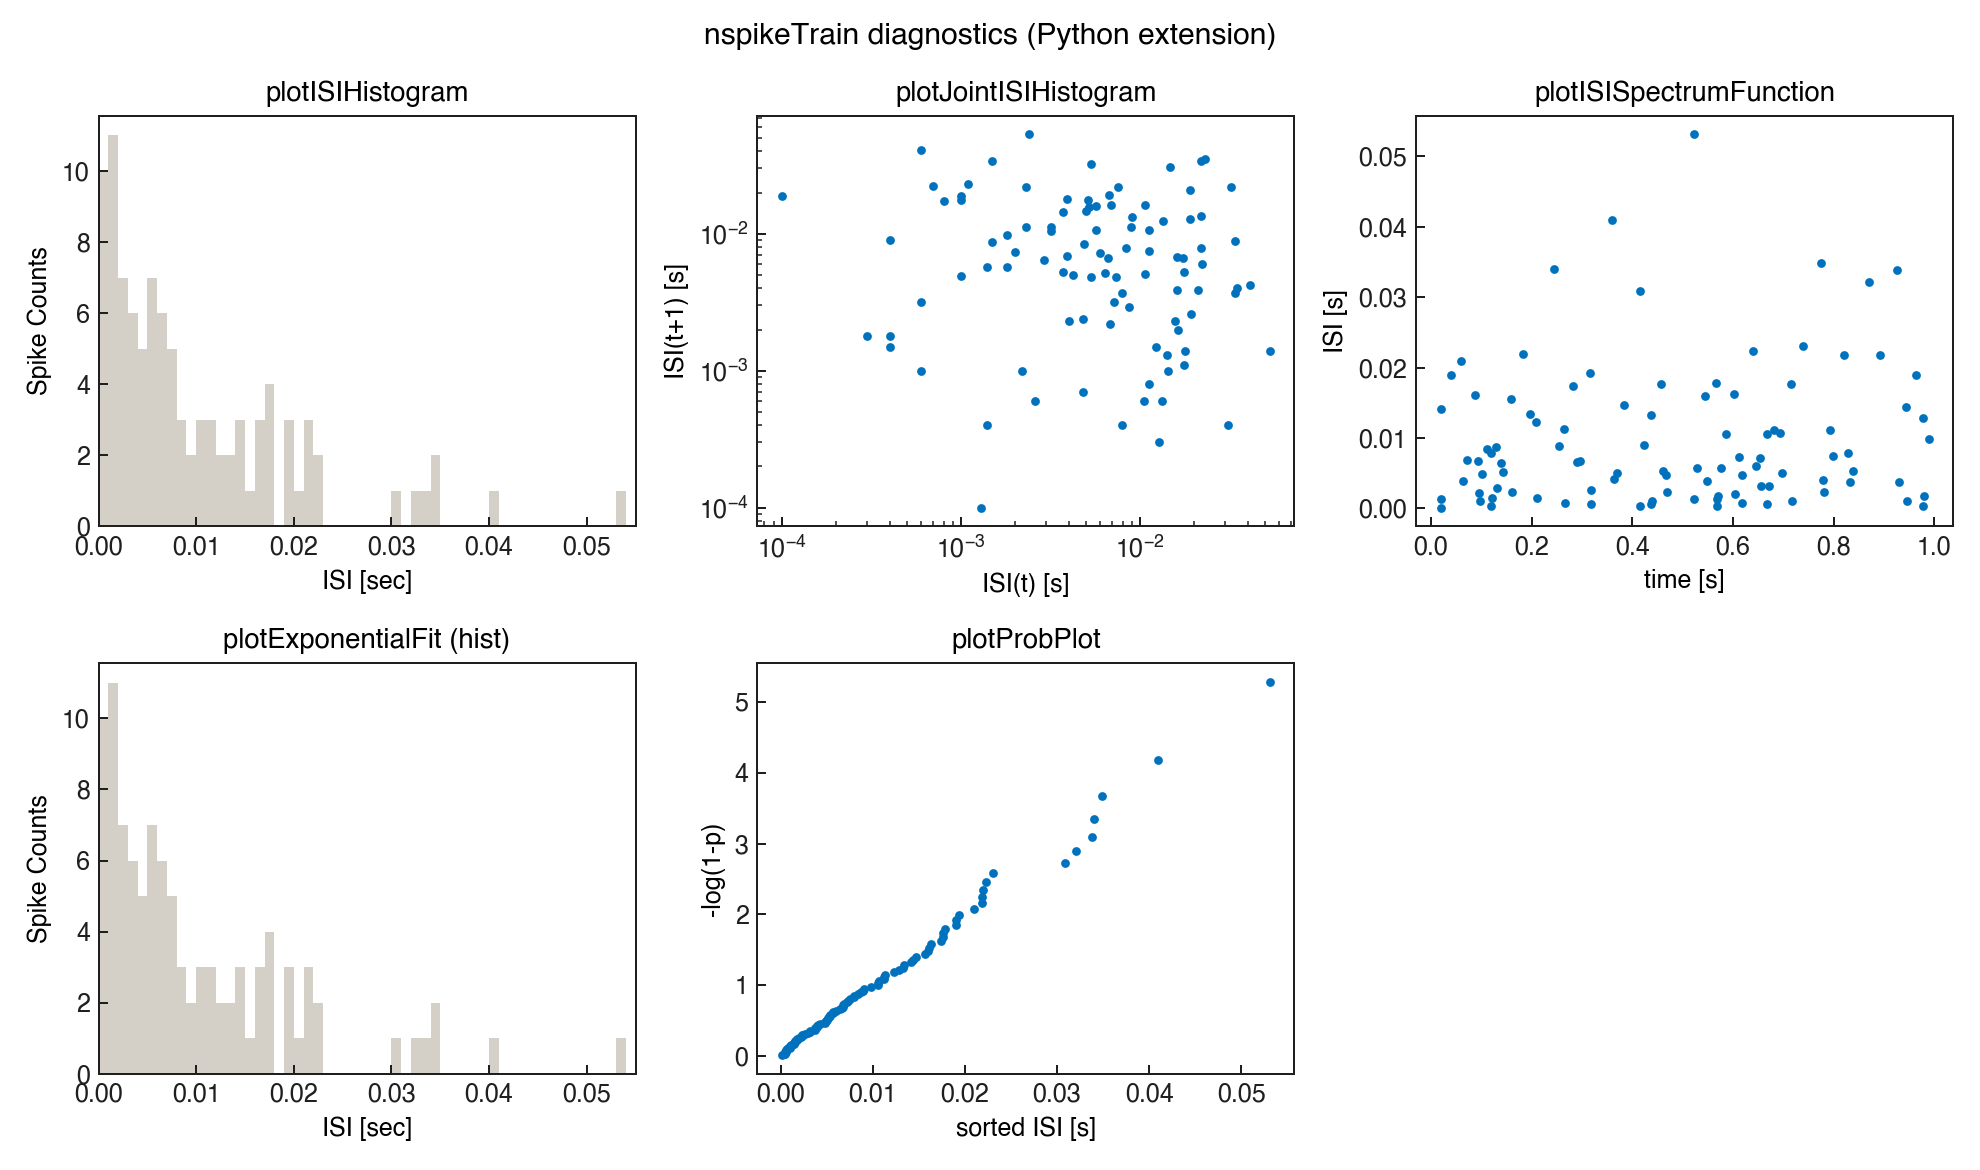

In [ ]:
# Python extension: diagnostic-suite composite (no MATLAB counterpart).
# Showcases the nspikeTrain ISI/joint-ISI/spectrum/exp-fit/prob-plot helpers
# in a single 2x3 figure.  Not a parity panel — kept after the MATLAB-mirror
# panels so the gallery's first 6 figures still align 1:1 with the helpfile.
def _diagnostics():
    fig = plt.gcf()
    fig.clear()
    fig.set_size_inches(11.0, 6.5)
    ax1 = fig.add_subplot(2, 3, 1)
    nst.plotISIHistogram(handle=ax1)
    ax1.set_title("plotISIHistogram")
    ax2 = fig.add_subplot(2, 3, 2)
    # plotJointISIHistogram opens its own axes; reuse ax2 by temporarily
    # making it current.
    plt.sca(ax2)
    isi = nst.getISIs()
    if isi.size >= 2:
        x = np.asarray(isi[:-1], dtype=float)
        y = np.asarray(isi[1:], dtype=float)
        ax2.loglog(x, y, ".")
    ax2.set_xlabel("ISI(t) [s]")
    ax2.set_ylabel("ISI(t+1) [s]")
    ax2.set_title("plotJointISIHistogram")
    ax3 = fig.add_subplot(2, 3, 3)
    isi_all = nst.getISIs()
    if isi_all.size:
        ax3.plot(nst.spikeTimes[1:], isi_all, ".")
    ax3.set_xlabel("time [s]")
    ax3.set_ylabel("ISI [s]")
    ax3.set_title("plotISISpectrumFunction")
    ax4 = fig.add_subplot(2, 3, 4)
    nst.plotISIHistogram(handle=ax4)
    ax4.set_title("plotExponentialFit (hist)")
    ax5 = fig.add_subplot(2, 3, 5)
    nst.plotProbPlot(handle=ax5)
    ax5.set_xlabel("sorted ISI [s]")
    ax5.set_ylabel("-log(1-p)")
    ax5.set_title("plotProbPlot")
    ax6 = fig.add_subplot(2, 3, 6)
    ax6.set_axis_off()
    fig.suptitle("nspikeTrain diagnostics (Python extension)")
    fig.tight_layout()

capture("nspikeTrain diagnostics composite (Python-only)", _diagnostics)
__tracker.finalize()
